This file contains the data analysis and inferences regarding the dataset 
The main objectives are
1) to tell how deviated the avg data is from all the files individually 
2) if all the flex sensor readings fall in the same range (max deviation acceptabel is 10%)
3) decide onto the best practices which I can partake in regarding this dataset, for now I plan to use xgboost or random forest.
4) also to check if there are some missing values in my data or not if yes manage it
5) it can also be used to do further encodings and labellings for future updates

Data ingestion
Getting the average files regarding the folders and comparing them simultaneously
Then checking it against the combined average too
and checking individual average to the combined averages

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Paths (change only if needed)
AVG_CSV_PATH = "dataset/all_mean_files/combined_alphabet_mean_dataset.csv"
RAW_BASE_DIR = "dataset"

# Flex sensors only
FLEX_COLS = ["flex_1", "flex_2", "flex_3", "flex_4", "flex_5"]


In [3]:
'''avg_df = pd.read_csv(AVG_CSV_PATH)
avg_df.head()
'''

'avg_df = pd.read_csv(AVG_CSV_PATH)\navg_df.head()\n'

In [4]:
def load_raw_flex_data(letter):
    letter = letter.lower()
    all_data = []

    for folder in os.listdir(RAW_BASE_DIR):
        if folder.isdigit():
            csv_path = os.path.join(
                RAW_BASE_DIR, folder, "alphabets", f"{letter}.csv"
            )

            if os.path.exists(csv_path):
                df = pd.read_csv(csv_path)
                all_data.append(df[FLEX_COLS])

    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        return None


In [5]:
'''letter = "A"

avg_row = avg_df[avg_df["label"] == letter].iloc[0]
raw_df = load_raw_flex_data(letter)

plt.figure()

for col in FLEX_COLS:
    plt.plot(raw_df[col].values, alpha=0.3)
    plt.hlines(
        avg_row[col],
        xmin=0,
        xmax=len(raw_df),
        linestyles="dashed"
    )

plt.title(f"Flex Sensor Validation for Alphabet '{letter}'")
plt.xlabel("Sample Index")
plt.ylabel("Flex Sensor Value")
plt.show()'''


'letter = "A"\n\navg_row = avg_df[avg_df["label"] == letter].iloc[0]\nraw_df = load_raw_flex_data(letter)\n\nplt.figure()\n\nfor col in FLEX_COLS:\n    plt.plot(raw_df[col].values, alpha=0.3)\n    plt.hlines(\n        avg_row[col],\n        xmin=0,\n        xmax=len(raw_df),\n        linestyles="dashed"\n    )\n\nplt.title(f"Flex Sensor Validation for Alphabet \'{letter}\'")\nplt.xlabel("Sample Index")\nplt.ylabel("Flex Sensor Value")\nplt.show()'

In [6]:
'''for _, avg_row in avg_df.iterrows():
    letter = avg_row["label"]

    raw_df = load_raw_flex_data(letter)
    if raw_df is None:
        continue

    plt.figure()

    for col in FLEX_COLS:
        plt.plot(raw_df[col].values, alpha=0.3)
        plt.hlines(
            avg_row[col],
            xmin=0,
            xmax=len(raw_df),
            linestyles="dashed"
        )

    plt.title(f"Flex Sensor Validation for Alphabet '{letter}'")
    plt.xlabel("Samp le Index")
    plt.ylabel("Flex Sensor Value")
    plt.show()'''


'for _, avg_row in avg_df.iterrows():\n    letter = avg_row["label"]\n\n    raw_df = load_raw_flex_data(letter)\n    if raw_df is None:\n        continue\n\n    plt.figure()\n\n    for col in FLEX_COLS:\n        plt.plot(raw_df[col].values, alpha=0.3)\n        plt.hlines(\n            avg_row[col],\n            xmin=0,\n            xmax=len(raw_df),\n            linestyles="dashed"\n        )\n\n    plt.title(f"Flex Sensor Validation for Alphabet \'{letter}\'")\n    plt.xlabel("Samp le Index")\n    plt.ylabel("Flex Sensor Value")\n    plt.show()'

In [7]:
'''print(os.listdir(RAW_BASE_DIR))'''

'print(os.listdir(RAW_BASE_DIR))'

In [8]:
'''BASE_DIR = "dataset"   # contains 001–025 folders
FLEX_COLS = ["flex_1", "flex_2", "flex_3", "flex_4", "flex_5"]'''

'BASE_DIR = "dataset"   # contains 001–025 folders\nFLEX_COLS = ["flex_1", "flex_2", "flex_3", "flex_4", "flex_5"]'

In [9]:
'''def plot_file_vs_own_mean(folder_id, letter):
    csv_path = os.path.join(
        BASE_DIR, folder_id, "alphabets", f"{letter.lower()}.csv"
    )

    if not os.path.exists(csv_path):
        return

    df = pd.read_csv(csv_path)

    # Compute mean from THIS file only
    mean_vals = df[FLEX_COLS].mean()

    plt.figure()

    for col in FLEX_COLS:
        plt.plot(df[col].values, alpha=0.4)
        plt.hlines(
            mean_vals[col],
            xmin=0,
            xmax=len(df),
            linestyles="dashed"
        )

    plt.title(f"Folder {folder_id} — Letter '{letter}' (Raw vs Own Mean)")
    plt.xlabel("Sample Index (Time Step)")
    plt.ylabel("Flex Sensor Value")
    plt.show()
'''

'def plot_file_vs_own_mean(folder_id, letter):\n    csv_path = os.path.join(\n        BASE_DIR, folder_id, "alphabets", f"{letter.lower()}.csv"\n    )\n\n    if not os.path.exists(csv_path):\n        return\n\n    df = pd.read_csv(csv_path)\n\n    # Compute mean from THIS file only\n    mean_vals = df[FLEX_COLS].mean()\n\n    plt.figure()\n\n    for col in FLEX_COLS:\n        plt.plot(df[col].values, alpha=0.4)\n        plt.hlines(\n            mean_vals[col],\n            xmin=0,\n            xmax=len(df),\n            linestyles="dashed"\n        )\n\n    plt.title(f"Folder {folder_id} — Letter \'{letter}\' (Raw vs Own Mean)")\n    plt.xlabel("Sample Index (Time Step)")\n    plt.ylabel("Flex Sensor Value")\n    plt.show()\n'

In [10]:
'''plot_file_vs_own_mean("001", "A")'''


'plot_file_vs_own_mean("001", "A")'

In [11]:
'''for folder in sorted(os.listdir(BASE_DIR)):
    if folder.isdigit():
        for letter in string.ascii_uppercase:
            plot_file_vs_own_mean(folder, letter)'''


'for folder in sorted(os.listdir(BASE_DIR)):\n    if folder.isdigit():\n        for letter in string.ascii_uppercase:\n            plot_file_vs_own_mean(folder, letter)'

Guess majority of values do lie in the mean range cool stuff 
There are some outliers (decide on the plan of action)
Lets make a model first from the average value data and then lets start fine tuning it. 

In [18]:

# Load datasets
train_df = pd.read_csv(r"C:\Users\pieush\Desktop\Root\Sign-to-Speech\dataset\master_alphabets_train.csv")
test_df = pd.read_csv(r"C:\Users\pieush\Desktop\Root\Sign-to-Speech\dataset\master_alphabets_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (780520, 24)
Test shape: (195105, 24)


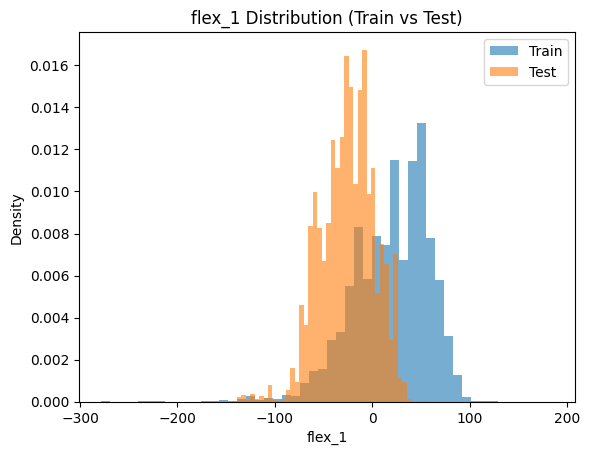

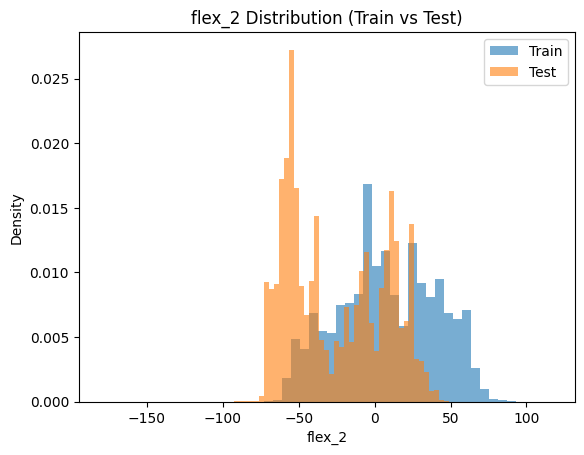

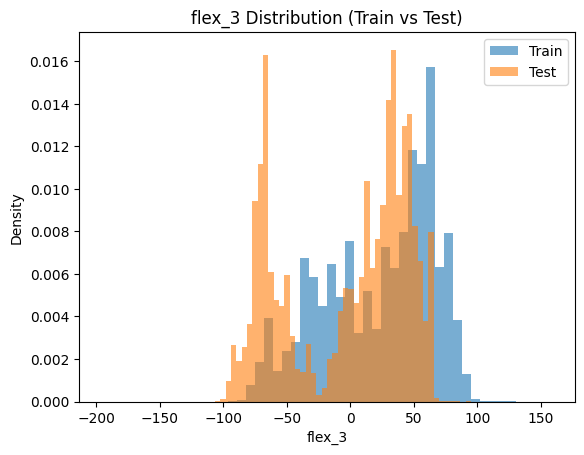

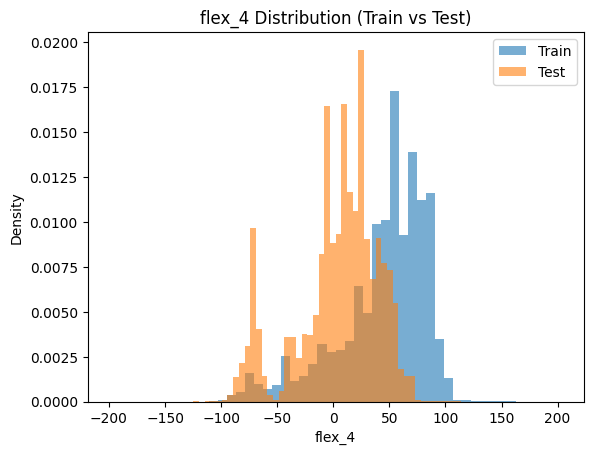

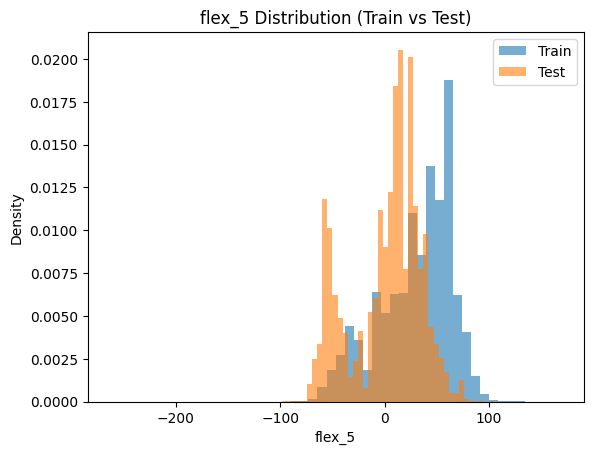

In [19]:
features = ["flex_1", "flex_2", "flex_3", "flex_4", "flex_5"]

for feature in features:
    plt.figure()
    
    plt.hist(train_df[feature], bins=50, alpha=0.6, label="Train", density=True)
    plt.hist(test_df[feature], bins=50, alpha=0.6, label="Test", density=True)
    
    plt.title(f"{feature} Distribution (Train vs Test)")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    
    plt.show()

In [ ]:
letter = "A"

for feature in features:
    plt.figure()
    
    plt.hist(
        train_df[train_df["label"] == letter][feature],
        bins=50,
        alpha=0.6,
        label="Train",
        density=True
    )
    
    plt.hist(
        test_df[test_df["label"] == letter][feature],
        bins=50,
        alpha=0.6,
        label="Test",
        density=True
    )
    
    plt.title(f"{feature} Distribution for {letter}")
    plt.legend()
    plt.show()